In [1]:
# importing libraries
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('https://raw.githubusercontent.com/thamidu02/AIML_project/refs/heads/main/data/balanced_data.csv')

In [3]:
data_df=pd.DataFrame(data)

In [4]:
data_df.head()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,stress_level,target,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
0,-0.516129,0.532513,-0.286205,-0.466182,-0.793095,-0.048494,-0.789323,-0.065063,1.116397,-0.901466,...,0.500000,healthy,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.451613,0.113444,0.428740,0.317736,0.882447,-0.423962,-0.704292,0.462630,-1.300426,0.015120,...,0.500000,healthy,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.193548,0.138622,-0.039458,-0.095566,0.390318,0.780589,0.265728,0.034614,-0.527712,-0.439868,...,0.833333,healthy,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.903226,1.063068,0.538649,-0.046443,0.080632,-1.164706,1.604822,-0.305074,0.264342,-1.125651,...,0.666667,healthy,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.483871,0.117415,0.888653,0.710070,0.229271,0.296010,0.186589,-0.014294,0.462007,-1.840230,...,-0.333333,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
data_df.columns

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'blood_pressure',
       'glucose', 'heart_rate', 'insulin', 'cholesterol', 'sugar_intake',
       'daily_steps', 'calorie_intake', 'daily_supplement_dosage',
       'water_intake', 'income', 'work_hours', 'sleep_hours',
       'work_sleep_balance', 'stress_level', 'target', 'gender_Female',
       'gender_Male', 'job_type_Healthcare', 'job_type_Labor',
       'job_type_Office', 'job_type_Service', 'job_type_Tech',
       'job_type_Unemployed'],
      dtype='object')

In [6]:
data_df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,work_sleep_balance,stress_level,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.003823,0.014309,0.032780,0.060644,0.020136,-0.012667,0.047228,-0.032690,-0.005951,0.003951,...,0.127052,0.003833,0.507500,0.492500,0.169500,0.173500,0.158500,0.159500,0.173000,0.166000
std,0.579284,0.744236,0.726317,0.754748,0.748494,0.766680,0.732374,0.808740,0.793466,0.729208,...,0.821018,0.523859,0.500069,0.500069,0.375287,0.378774,0.365301,0.366233,0.378342,0.372174
min,-0.967742,-2.155411,-1.488155,-1.665177,-2.494987,-2.878071,-2.300899,-2.939604,-2.204649,-2.315525,...,-1.997276,-0.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.483871,-0.491521,-0.458288,-0.475792,-0.499730,-0.547553,-0.461426,-0.531622,-0.531502,-0.481871,...,-0.434426,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.009024,0.041447,0.040722,0.033636,0.002023,0.050934,-0.012009,0.003476,0.022496,...,0.018831,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.516129,0.504253,0.517436,0.545119,0.538444,0.507939,0.536331,0.473686,0.505658,0.495660,...,0.527461,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.585270,2.945759,3.127637,2.701138,2.501723,2.434811,2.967024,2.254904,3.201732,...,5.145421,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
len(data_df.columns)

29

In [8]:
# splitting the target variable and input data
X,y=data_df.drop('target',axis=1),data_df['target']

In [9]:
data_df.target.value_counts()

target
healthy     1000
diseased    1000
Name: count, dtype: int64

In [10]:
# encoding the target variable
y=np.where(y=='healthy',1,0)

In [11]:
# splitting into train set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

In [13]:
# making the neural network with 5 hidden layers
inputs=keras.Input(shape=(X_train.shape[1],))
x=layers.Dense(256,activation='relu')(inputs)
x=layers.Dense(128,activation='relu')(x)
x=layers.Dense(64,activation='relu')(x)
x=layers.Dense(32,activation='relu')(x)
x=layers.Dense(16,activation='relu')(x)
x=layers.Dense(8,activation='relu')(x)
outputs=layers.Dense(1,activation='sigmoid')(x)
model=keras.Model(inputs=inputs,outputs=outputs)

In [14]:
# model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,329 (200.50 KB)

 Trainable params: 51,329 (200.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# model vissualization
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [16]:
# compilation of the model
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history=model.fit(X_train,y_train,
                  batch_size=32,
                  epochs=50,
                  validation_split=0.2)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4863 - loss: 387.9871 - val_accuracy: 0.5312 - val_loss: 0.7021
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4813 - loss: 0.7786 - val_accuracy: 0.4563 - val_loss: 0.7015
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4633 - loss: 0.6971 - val_accuracy: 0.4563 - val_loss: 0.7318
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5017 - loss: 0.6997 - val_accuracy: 0.4563 - val_loss: 0.6935
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5253 - loss: 0.6950 - val_accuracy: 0.4563 - val_loss: 0.6963
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5036 - loss: 0.6950 - val_accuracy: 0.4563 - val_loss: 0.6948
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5198 - loss: 0.6937 - val_accuracy: 0.5437 - val_loss: 0.6895
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5012 - loss: 0.6962 - val_accuracy: 0.4563 - val_los

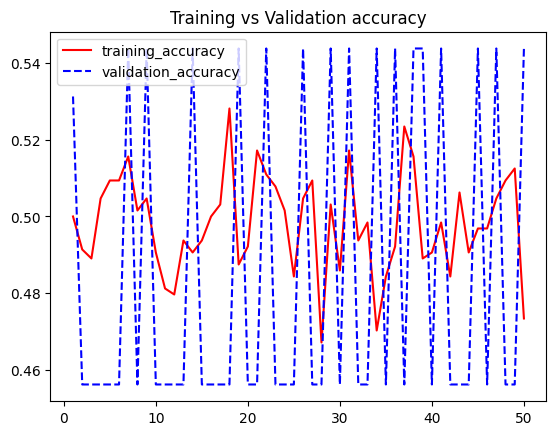

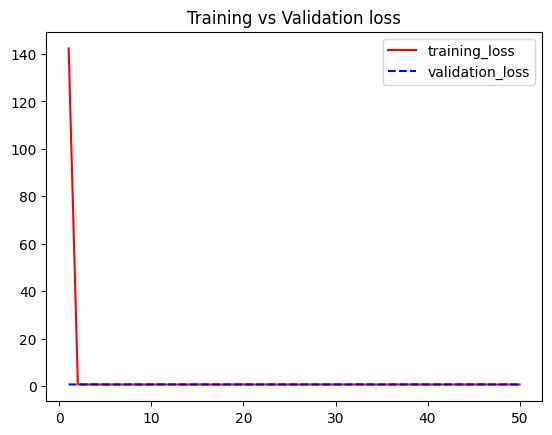

In [18]:
train_acc=history.history['accuracy']
train_loss=history.history['loss']
val_acc=history.history['val_accuracy']
val_loss=history.history['val_loss']
epochs=range(1,len(train_acc)+1) # Changed epochs to a range

plt.plot(epochs,train_acc,'b-',c='red',label='training_accuracy')
plt.plot(epochs,val_acc,'b--',c='blue',label='validation_accuracy')
plt.title('Training vs Validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs,train_loss,'b-',c='red',label='training_loss')
plt.plot(epochs,val_loss,'b--',c='blue',label='validation_loss')
plt.title('Training vs Validation loss')
plt.legend()
plt.show()

In [19]:
print(f"Test set score: {model.evaluate(X_test,y_test)}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4833 - loss: 0.6936  
Test set score: [0.6932199597358704, 0.5]


In [20]:
from sklearn.metrics import classification_report
y_pred=model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)
print(classification_report(y_test,y_pred_binary))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       200
           1       0.50      1.00      0.67       200

    accuracy                           0.50       400
   macro avg       0.25      0.50      0.33       400
weighted avg       0.25      0.50      0.33       400



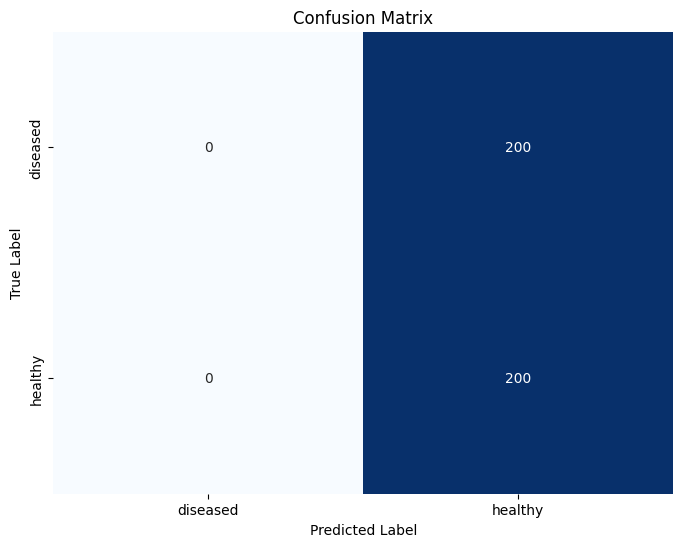

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['diseased', 'healthy'], yticklabels=['diseased', 'healthy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [28]:
# neural network with batch normalization and dynamic learning rate
inputs=keras.Input(shape=(X_train.shape[1],))
x=layers.Dense(256,activation='relu')(inputs)
x=layers.BatchNormalization()(x)
x=layers.Dense(128,activation='relu')(x)
x=layers.BatchNormalization()(x)
x=layers.Dense(64,activation='relu')(x)
x=layers.BatchNormalization()(x)
x=layers.Dense(32,activation='relu')(x)
x=layers.BatchNormalization()(x)
x=layers.Dense(16,activation='relu')(x)
x=layers.BatchNormalization()(x)
x=layers.Dense(8,activation='relu')(x)
x=layers.Dropout(0.5)(x)
outputs=layers.Dense(1,activation='sigmoid')(x)
model2=keras.Model(inputs=inputs,outputs=outputs)

In [29]:

from tensorflow.keras.callbacks import LearningRateScheduler

# defining a dynamic learning rate before epoch 10 its 0.01 and after 0.001 doing this for better model convergence
def scheduler(epoch, lr):
  if epoch < 20:
    return lr
  else:
    return lr * 0.1

lr_scheduler = LearningRateScheduler(scheduler)

In [30]:
model2.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
history2=model2.fit(X_train,y_train,
                  batch_size=32,
                  epochs=50,
                  validation_split=0.2,
                  callbacks=[lr_scheduler])

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4867 - loss: 0.8399 - val_accuracy: 0.4594 - val_loss: 0.7049 - learning_rate: 0.0100
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4973 - loss: 0.7064 - val_accuracy: 0.4656 - val_loss: 0.7033 - learning_rate: 0.0100
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5466 - loss: 0.6943 - val_accuracy: 0.4531 - val_loss: 0.7083 - learning_rate: 0.0100
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5117 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6983 - learning_rate: 0.0100
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5484 - loss: 0.6904 - val_accuracy: 0.5063 - val_loss: 0.6968 - learning_rate: 0.0100
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5044 - loss: 0.6948 - val_accuracy: 0.4344 - val_loss: 0.7729 - learning_rate: 0.0100
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5242 - loss: 0.6964 - val_accurac

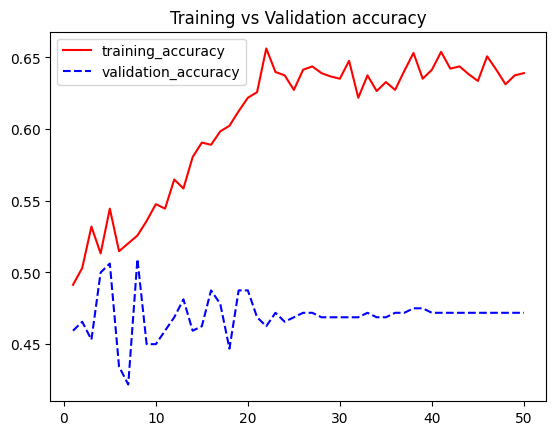

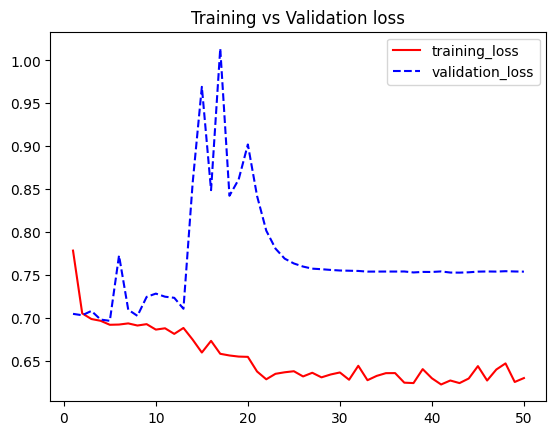

In [32]:
train_acc=history2.history['accuracy']
train_loss=history2.history['loss']
val_acc=history2.history['val_accuracy']
val_loss=history2.history['val_loss']
epochs=range(1,len(train_acc)+1) # Changed epochs to a range

plt.plot(epochs,train_acc,'b-',c='red',label='training_accuracy')
plt.plot(epochs,val_acc,'b--',c='blue',label='validation_accuracy')
plt.title('Training vs Validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs,train_loss,'b-',c='red',label='training_loss')
plt.plot(epochs,val_loss,'b--',c='blue',label='validation_loss')
plt.title('Training vs Validation loss')
plt.legend()
plt.show()

In [34]:
_,test_accuracy=model2.evaluate(X_test,y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4920 - loss: 0.7439  
Test accuracy: 0.4950
